In [ ]:
import pandas as pd
import numpy as np
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from matplotlib import pyplot as plt

# =====================================================================
# 1. PREPARACIÓN DE LOS DATOS
# =====================================================================

In [ ]:
print("Cargando la base de datos de Malaria...")
df = pd.read_csv('Malaria Diseases dataset - .csv')

Cargando la base de datos de Malaria...


In [ ]:
# Binarizar textos del nuevo dataset
df['Sex'] = df['Sex'].map({'Male': 0, 'Female': 1})

In [ ]:
categorias_originales = list(df['Result'].astype('category').cat.categories)
df['Result'] = df['Result'].astype('category').cat.codes
df.dropna(inplace=True)
print("Categorías:", categorias_originales)  # ['negative', 'positive']

Categorías: ['negative', 'positive']


In [ ]:
Y = df['Result'].values
columnas = ["Sex", "Age", "Hemoglobin(Hb%)", "Total WBC count(/cumm)",
            "Neutrophils", "Lymphocytes", "Total Cir.Eosinophils",
            "HTC/PCV(%)", "MCH(pg)", "MCHC(g/dl)", "RDW-CV(%)", "Platelet Count"]
X = df[list(columnas)].values

# NUEVO: Escalado de variables
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
joblib.dump(scaler, "scaler_malaria.pkl")
print("✅ Escalador de datos guardado como 'scaler_malaria.pkl'")

✅ Escalador de datos guardado como 'scaler_malaria.pkl'


In [ ]:
# Calcular pesos para balancear clases
pesos = compute_class_weight('balanced', classes=np.unique(Y), y=Y)
class_weight_dict = dict(enumerate(pesos))
print("Pesos por clase:", class_weight_dict)

Pesos por clase: {0: np.float64(0.9759358288770054), 1: np.float64(1.0252808988764044)}


# =====================================================================
# 2. ARQUITECTURA Y ENTRENAMIENTO DE LA RED NEURONAL
# =====================================================================

In [ ]:
print("\n--- ENTRENANDO RED NEURONAL ---")
modelo_rn = Sequential()
modelo_rn.add(Dense(32, input_dim=12, activation='relu'))
modelo_rn.add(Dense(16, activation='relu'))
modelo_rn.add(Dense(8, activation='relu'))
modelo_rn.add(Dense(2, activation='softmax'))


--- ENTRENANDO RED NEURONAL ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compilamos usando la función para múltiples opciones
modelo_rn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Entrenamos con el 100% de X e Y
modelo_rn.fit(X, Y, epochs=100, batch_size=10,            # ← de 50 a 100
              class_weight=class_weight_dict,
              verbose=1)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6187 - loss: 0.6359
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6986 - loss: 0.5779
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7082 - loss: 0.5571
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7187 - loss: 0.5439
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7301 - loss: 0.5325
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7342 - loss: 0.5229
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7443 - loss: 0.5130
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7466 - loss: 0.5057
Epoch 9/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7493 - loss: 0.5008
Epoch 10/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7584 - loss: 0.4935
Epoch 11/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7653 - loss: 0.4882
Epoch 12/100
219/219 ━━━━━━━━━━━━━━━━━━━━

# =====================================================================
# 3. PREDICCIÓN Y EVALUACIÓN
# =====================================================================

In [ ]:
print("\n--- EVALUACIÓN DEL MODELO ---")
# La red escupe 2 probabilidades, np.argmax elige la más alta
Ypredecido_rn_prob = modelo_rn.predict(X)
Ypredecido_rn = np.argmax(Ypredecido_rn_prob, axis=1)


--- EVALUACIÓN DEL MODELO ---
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
conf_mat_rn = confusion_matrix(y_true=Y, y_pred=Ypredecido_rn)
print('\nMatriz de Confusión - RED NEURONAL:\n', conf_mat_rn)
print('Métricas de Matriz de Confusión - RED NEURONAL:\n', classification_report(Y, Ypredecido_rn, target_names=['Negativo', 'Positivo']))


Matriz de Confusión - RED NEURONAL:
 [[ 999  123]
 [  51 1017]]
Métricas de Matriz de Confusión - RED NEURONAL:
               precision    recall  f1-score   support

    Negativo       0.95      0.89      0.92      1122
    Positivo       0.89      0.95      0.92      1068

    accuracy                           0.92      2190
   macro avg       0.92      0.92      0.92      2190
weighted avg       0.92      0.92      0.92      2190



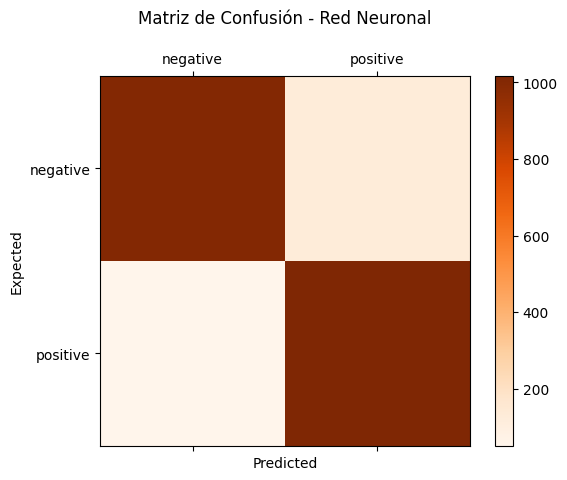

In [ ]:
# Graficamos la precisión y la pérdida (como en tu entorno original)
labels = categorias_originales
fig2 = plt.figure()
ax2 = fig2.add_subplot(111)
cax2 = ax2.matshow(conf_mat_rn, cmap=plt.cm.Oranges)
fig2.colorbar(cax2)

ax2.set_xticks(np.arange(len(labels)))
ax2.set_yticks(np.arange(len(labels)))
ax2.set_xticklabels(labels)
ax2.set_yticklabels(labels)

plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.title('Matriz de Confusión - Red Neuronal\n')
plt.show()

In [ ]:
with open("malaria_rn.json", "w") as json_file:
    json_file.write(modelo_rn.to_json())
modelo_rn.save_weights("malaria_rn.weights.h5")

print("\n✅ Red Neuronal guardada correctamente como 'malaria_rn.json' y 'malaria_rn.weights.h5'")


✅ Red Neuronal guardada correctamente como 'malaria_rn.json' y 'malaria_rn.weights.h5'
